In [94]:
# ----------------------------------
# Step 1: Set Up Evaluation Script
# ----------------------------------

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# ----------------------------------
# 1. Define Paths
# ----------------------------------

# Paths to the data folders
fpi_dist_folder = r"C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\data\mms1\fpi\brst\l2\des-dist\2024\03\01"
fgm_folder = r"C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\data\mms1\fgm"
fpi_moms_folder = r"C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\data\mms1\fpi\brst\l2\des-moms\2024\03\01"

# Path to the fine-tuned model
fine_tuned_model_path = r"C:\Users\ryane\Desktop\Aurora_Project\MMS-FPI-Data-Gaps\model_3_10.h5"

# ----------------------------------
# 2. Load the Fine-Tuned Model
# ----------------------------------

# Verify that the model file exists
if not os.path.exists(fine_tuned_model_path):
    raise FileNotFoundError(f"Fine-tuned model file not found at: {fine_tuned_model_path}")
else:
    print("Fine-tuned model file found. Proceeding to load.")

# Load the fine-tuned model
try:
    fine_tuned_model = load_model(fine_tuned_model_path)
    print("Fine-tuned model loaded successfully.")
    fine_tuned_model.summary()
except Exception as e:
    raise ValueError(f"Error loading the fine-tuned model: {e}")


Fine-tuned model file found. Proceeding to load.
Fine-tuned model loaded successfully.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_po

Total params: 13118848 (50.04 MB)
Trainable params: 2150016 (8.20 MB)
Non-trainable params: 10968832 (41.84 MB)
__________________________________________________________________________________________________


In [95]:
# ----------------------------------
# Step 2: Match and Load the Test Data
# ----------------------------------

import datetime
from scipy.interpolate import interp1d
import cdflib

# ----------------------------------
# Helper Functions for Matching and Loading Data
# ----------------------------------

def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

# Match the files
matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)

if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

# Select the first matched file set for processing
fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename = matched_files[0]

print("\nSelected Matched File Set for Testing:")
print(f"  FPI Distribution File: {fpi_dist_filename}")
print(f"  FGM File: {fgm_filename}")
print(f"  FPI Moments File: {fpi_moms_filename}")

# Define file paths
fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
fgm_filepath = os.path.join(fgm_folder, fgm_filename)
fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)

# ----------------------------------
# Step 3: Load and Preprocess the Data
# ----------------------------------

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')
        theta = fpi_cdf.varget('mms1_des_theta_brst')
        phi = fpi_cdf.varget('mms1_des_phi_brst')
        energy = fpi_cdf.varget('mms1_des_energy_brst')
    return epoch, dist_data, theta, phi, energy

def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')
    return epoch, bulk_velocity

# Load data from the matched files
fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)
moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)

print("Data loaded successfully.")


No matching FPI Moments file for timestamp 2024-03-01 23:22:33
No matching FPI Moments file for timestamp 2024-03-01 23:29:13

Selected Matched File Set for Testing:
  FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
  FGM File: mms1_fgm_brst_l2_20240301230743_v5.441.0.cdf
  FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230743_v3.4.0.cdf
Data loaded successfully.


In [96]:
# ----------------------------------
# Step 3: Preprocess the Data
# ----------------------------------

from scipy.interpolate import interp1d
import numpy as np

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """
    Interpolate magnetic field data to match FPI timestamps.
    """
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """
    Calculate pitch angle distribution using look direction (phi, theta) and magnetic field.
    """
    theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
    phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)
    look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
    look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
    look_direction_z = np.cos(theta_grid)
    look_direction = np.stack([look_direction_x, look_direction_y, look_direction_z], axis=2)  # (phi_bins, theta_bins, 3)

    # Flatten look_direction for efficient computation
    look_direction_flat = look_direction.reshape(-1, 3)  # (phi_bins * theta_bins, 3)
    pitch_angles = np.zeros((b_field.shape[0], phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

    for t in range(b_field.shape[0]):
        b_unit = b_field[t, :3] / np.linalg.norm(b_field[t, :3]) if np.linalg.norm(b_field[t, :3]) > 0 else np.zeros(3)
        v_dot_b = np.dot(look_direction_flat, b_unit)  # (phi_bins * theta_bins,)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)
        pitch_angles[t] = np.arccos(v_dot_b).reshape(phi_bins.size, theta_bins.size) * (180.0 / np.pi)

    return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)

# Interpolate magnetic field data to match FPI timestamps
b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
print("Magnetic field data interpolated to FPI timestamps.")

# Extract phi and theta bins
phi_bins = phi[0] if phi.ndim == 2 else phi  # (phi_bins,)
theta_bins = theta[0] if theta.ndim == 2 else theta  # (theta_bins,)

# Calculate pitch angles
pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
pitch_angles_normalized = pitch_angles / 180.0  # Normalize to [0, 1]
print(f"Pitch angles calculated and normalized. Shape: {pitch_angles_normalized.shape}")

# Transpose dist_data if needed for consistency
if dist_data.shape[1:] == (phi_bins.size, theta_bins.size, energy.size):
    dist_data_transposed = dist_data.transpose(0, 3, 2, 1)  # (time_steps, phi_bins, theta_bins, energy_levels)
else:
    dist_data_transposed = dist_data

print(f"Distribution data shape after transpose: {dist_data_transposed.shape}")

# Expand pitch_angles to align with dist_data
pitch_angles_expanded = pitch_angles_normalized[..., np.newaxis]  # Add a new axis for concatenation
X_data = np.concatenate((dist_data_transposed, pitch_angles_expanded), axis=3).astype('float32')  # (time_steps, phi_bins, theta_bins, 33)
print(f"Prepared input data shape: {X_data.shape}")

# ----------------------------------
# Step 4: Split Data into Sets
# ----------------------------------

# Define split proportions
total_samples = X_data.shape[0]
n_train = int(0.8 * total_samples)
k_val = int(0.1 * total_samples)
k_test = total_samples - n_train - k_val

# Split the data
X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:]




print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

# Reshape for model input (time_steps=1)
X_train = X_train.reshape((X_train.shape[0], 1, *X_train.shape[1:]))
X_val = X_val.reshape((X_val.shape[0], 1, *X_val.shape[1:]))
X_test = X_test.reshape((X_test.shape[0], 1, *X_test.shape[1:]))

print("Data reshaped for model input.")
print(f"Training data reshaped to: {X_train.shape}")
print(f"Validation data reshaped to: {X_val.shape}")
print(f"Test data reshaped to: {X_test.shape}")


Magnetic field data interpolated to FPI timestamps.
Pitch angles calculated and normalized. Shape: (4333, 32, 16)
Distribution data shape after transpose: (4333, 32, 16, 32)
Prepared input data shape: (4333, 32, 16, 33)
Training data shape: (3466, 32, 16, 33)
Validation data shape: (433, 32, 16, 33)
Test data shape: (434, 32, 16, 33)
Data reshaped for model input.
Training data reshaped to: (3466, 1, 32, 16, 33)
Validation data reshaped to: (433, 1, 32, 16, 33)
Test data reshaped to: (434, 1, 32, 16, 33)


In [97]:
# Function to apply mask
def apply_mask(X, mask):
    """
    Apply a 2D mask to the distribution data channels (0-31).

    Parameters:
    - X: Input data array of shape (samples, time_steps, phi_bins, theta_bins, channels)
    - mask: 2D boolean array of shape (phi_bins, theta_bins)

    Returns:
    - X_masked: Masked data array
    """
    # Expand mask dimensions to match X shape
    mask_expanded = mask[np.newaxis, np.newaxis, :, :, np.newaxis]  # (1, 1, phi_bins, theta_bins, 1)
    mask_broadcast = np.tile(mask_expanded, (X.shape[0], X.shape[1], 1, 1, X.shape[4]))  # (samples, time_steps, phi_bins, theta_bins, channels)

    # Set masked regions to 0.0 in the distribution data channels (channels 0-31)
    X_masked = X.copy()
    X_masked[..., :32][mask_broadcast[..., 0]] = 0.0  # Assuming channels 0-31 are energy levels

    return X_masked

# Define the 2D mask
mask_2d = np.zeros((X_test.shape[2], X_test.shape[3]), dtype=bool)  # (phi_bins, theta_bins)
mask_2d[:, X_test.shape[3]//2:] = True  # Masking the right half

# Apply the mask to the test set
X_test_masked = apply_mask(X_test, mask_2d)
print("Mask applied to test set.")


Mask applied to test set.


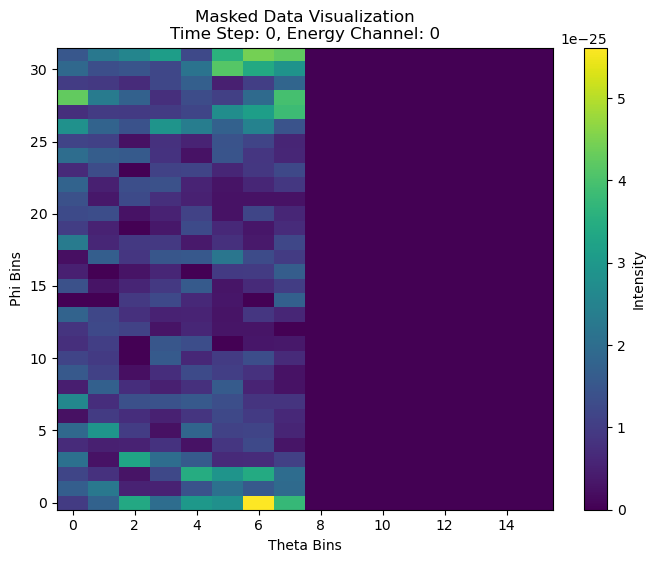

In [98]:
import matplotlib.pyplot as plt

def plot_time_step_example(X_test_masked, time_step=0, energy_channel=0):
    """
    Plot a single Phi-Theta slice of the masked data for a specific time step and energy channel.

    Parameters:
    - X_test_masked: Masked test data (time_steps, 1, phi_bins, theta_bins, channels).
    - time_step: The time step to visualize.
    - energy_channel: The energy channel to visualize.
    """
    # Extract the specific slice for the given time step and energy channel
    data_slice = X_test_masked[time_step, 0, :, :, energy_channel]
    
    # Plot the slice
    plt.figure(figsize=(8, 6))
    plt.imshow(data_slice, aspect='auto', origin='lower', cmap='viridis')
    plt.title(f'Masked Data Visualization\nTime Step: {time_step}, Energy Channel: {energy_channel}')
    plt.xlabel('Theta Bins')
    plt.ylabel('Phi Bins')
    plt.colorbar(label='Intensity')
    plt.show()

# Example usage
plot_time_step_example(X_test_masked, time_step=0, energy_channel=0)


In [177]:
# Step 1: Predict the entire cuboid
print("Predicting the masked test data...")
# final_predictions = fine_tuned_model.predict(X_test_masked)
final_predictions = fine_tuned_model.predict(X_test)
print("Prediction completed.")



Predicting the masked test data...
14/14 [==============================] - 0s 17ms/step
Prediction completed.


In [165]:
X_test_squeezed = np.squeeze(X_test, axis=1)  # Remove the redundant dimension

X_test_squeezed.shape

(434, 32, 16, 33)

In [155]:
phi_bins, theta_bins = mask_2d.shape

# Replace the left-hand side using slicing
for t in range(final_predictions.shape[0]):  # Iterate over time steps
    for ch in range(32):  # Iterate over energy channels
        # Copy the unmasked regions (left-hand side) from the original X_test
        final_predictions[t, :, :theta_bins // 2, ch] = X_test_squeezed[t, :, :theta_bins // 2, ch]

print("Replaced the left-hand side of the predicted cuboid with actual values.")

Replaced the left-hand side of the predicted cuboid with actual values.


In [166]:
# Check the left-hand side after replacement
for t in range(final_predictions.shape[0]):  # Iterate over time steps
    for ch in range(32):  # Iterate over energy channels
        left_predicted = final_predictions[t, :, :theta_bins // 2, ch]  # Left side of prediction
        left_actual = X_test_squeezed[t, :, :theta_bins // 2, ch]       # Left side of actual

        if not np.allclose(left_predicted, left_actual, atol=1e-8):     # Check if they match
            print(f"Mismatch at time {t}, channel {ch}")
            print(f"Predicted (Left): {left_predicted}")
            print(f"Actual (Left): {left_actual}")


In [167]:
# Check if the replacement is confined to the left-hand side
for t in range(final_predictions.shape[0]):
    for ch in range(32):
        right_predicted = final_predictions[t, :, theta_bins // 2:, ch]  # Right side of prediction
        left_predicted = final_predictions[t, :, :theta_bins // 2, ch]   # Left side of prediction

        if np.any(right_predicted == X_test_squeezed[t, :, theta_bins // 2:, ch]):
            print(f"Error: Right-hand side contains values from X_test_squeezed at time {t}, channel {ch}")


In [173]:
# Ensure non-negativity
final_predictions[final_predictions < 0] = 0

# Extract left-hand side statistics (actual values from X_test_squeezed)
left_actual = X_test_squeezed[..., :theta_bins // 2]
left_mean = np.mean(left_actual)
left_std = np.std(left_actual)
left_min = np.min(left_actual)
left_max = np.max(left_actual)

# Extract right-hand side predictions
right_predicted = final_predictions[..., theta_bins // 2:]

# Scale right-hand side predictions
# Option 1: Range Normalization
right_predicted = (right_predicted - np.min(right_predicted)) / (np.max(right_predicted) - np.min(right_predicted))
right_predicted = right_predicted * (left_max - left_min) + left_min

# Option 2: Z-Score Scaling
right_predicted = (right_predicted - np.mean(right_predicted)) / np.std(right_predicted)
right_predicted = right_predicted * left_std + left_mean

# Replace the right-hand side in final_predictions
final_predictions[..., theta_bins // 2:] = right_predicted

print("Aggressive scaling applied to right-hand side predictions.")


Aggressive scaling applied to right-hand side predictions.


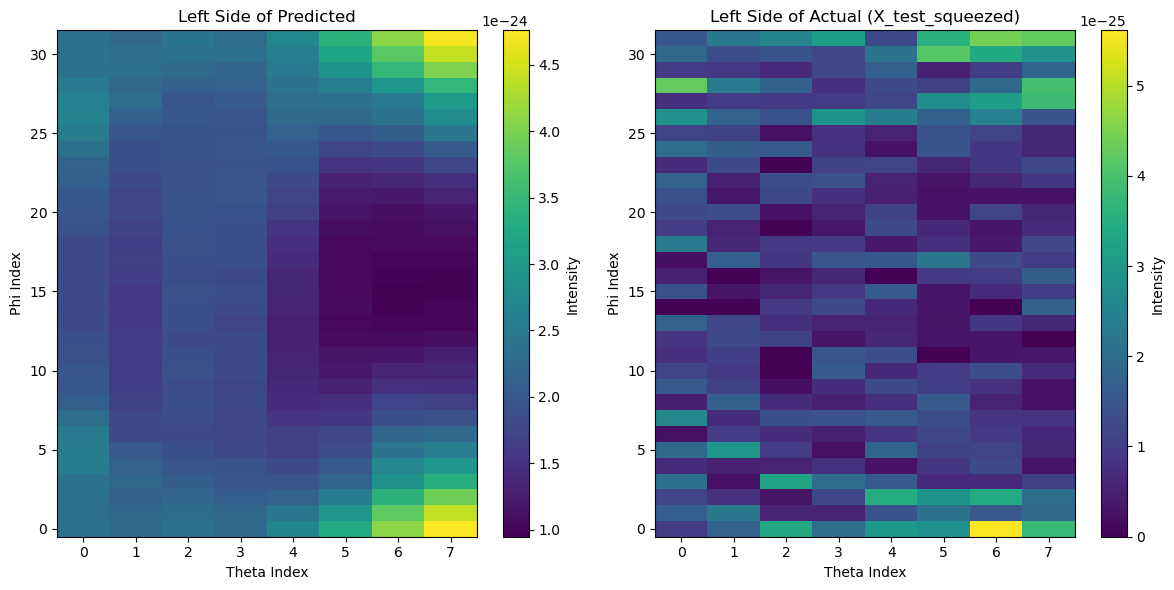

In [169]:
import matplotlib.pyplot as plt

# Select time and energy level to visualize
time_index = 0
energy_channel = 0

# Extract the left side of the prediction and actual for comparison
left_predicted = final_predictions[time_index, :, :theta_bins // 2, energy_channel]
left_actual = X_test_squeezed[time_index, :, :theta_bins // 2, energy_channel]

# Plot the left-hand side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the left side of the predicted values
im1 = axes[0].imshow(left_predicted, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title("Left Side of Predicted")
axes[0].set_xlabel("Theta Index")
axes[0].set_ylabel("Phi Index")
plt.colorbar(im1, ax=axes[0], label='Intensity')

# Plot the left side of the actual values
im2 = axes[1].imshow(left_actual, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title("Left Side of Actual (X_test_squeezed)")
axes[1].set_xlabel("Theta Index")
axes[1].set_ylabel("Phi Index")
plt.colorbar(im2, ax=axes[1], label='Intensity')

plt.tight_layout()
plt.show()


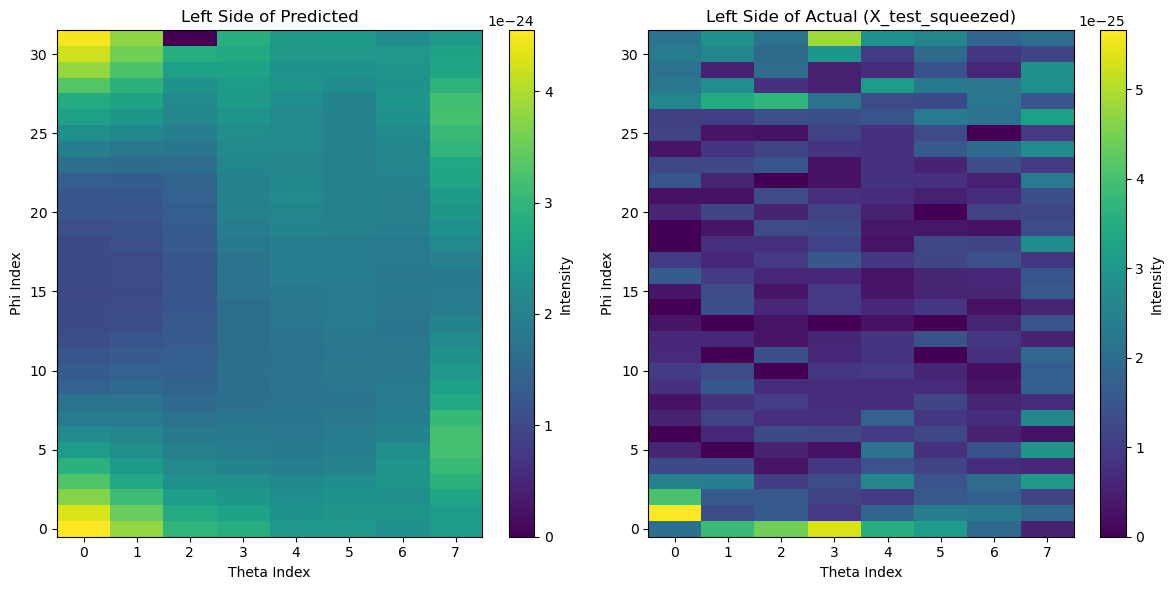

In [175]:
import matplotlib.pyplot as plt

# Select time and energy level to visualize
time_index = 0
energy_channel = 0

# Extract the left side of the prediction and actual for comparison
left_predicted = final_predictions[time_index, :, theta_bins // 2:, energy_channel]
left_actual = X_test_squeezed[time_index, :, theta_bins // 2:, energy_channel]

# Plot the left-hand side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the left side of the predicted values
im1 = axes[0].imshow(left_predicted, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title("Left Side of Predicted")
axes[0].set_xlabel("Theta Index")
axes[0].set_ylabel("Phi Index")
plt.colorbar(im1, ax=axes[0], label='Intensity')

# Plot the left side of the actual values
im2 = axes[1].imshow(left_actual, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title("Left Side of Actual (X_test_squeezed)")
axes[1].set_xlabel("Theta Index")
axes[1].set_ylabel("Phi Index")
plt.colorbar(im2, ax=axes[1], label='Intensity')

plt.tight_layout()
plt.show()

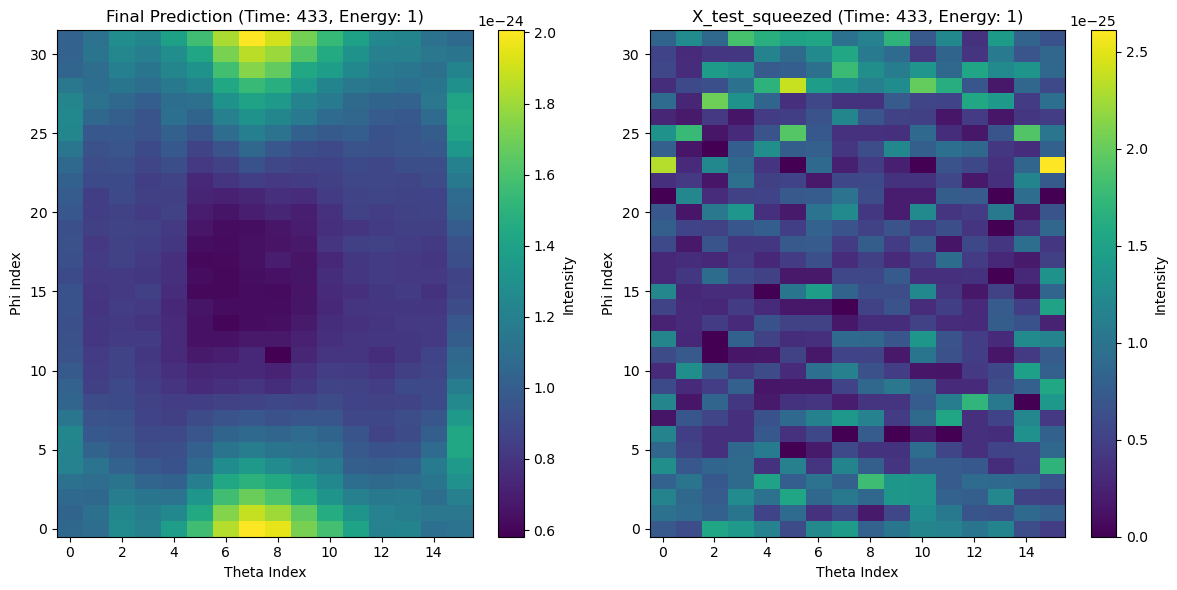

In [178]:
import matplotlib.pyplot as plt

# Choose a specific time step and energy channel to visualize
time_step = 433  # Example: 0th time step
energy_channel = 1  # Example: 0th energy channel

# Extract the slices for the chosen time step and energy channel
final_prediction_slice = final_predictions[time_step, :, :, energy_channel]
x_test_squeezed_slice = X_test_squeezed[time_step, :, :, energy_channel]

# Plotting
plt.figure(figsize=(12, 6))

# Plot final_predictions slice
plt.subplot(1, 2, 1)
plt.imshow(final_prediction_slice, aspect='auto', origin='lower', cmap='viridis')
plt.title(f'Final Prediction (Time: {time_step}, Energy: {energy_channel})')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.colorbar(label='Intensity')

# Plot X_test_squeezed slice
plt.subplot(1, 2, 2)
plt.imshow(x_test_squeezed_slice, aspect='auto', origin='lower', cmap='viridis')
plt.title(f'X_test_squeezed (Time: {time_step}, Energy: {energy_channel})')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()


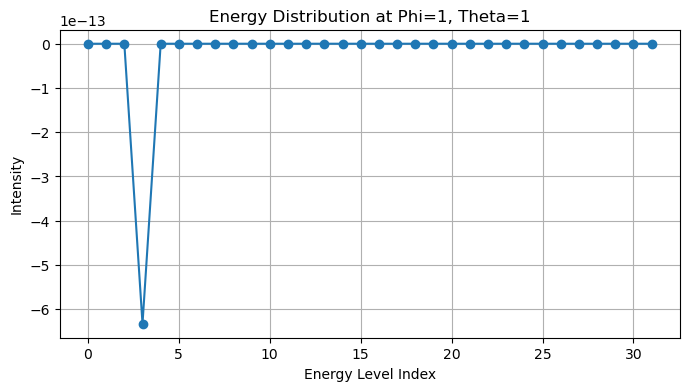

In [186]:
phi_bin = 1  # First phi bin
theta_bin = 1  # First theta bin
energy_levels = np.arange(32)  # Assuming 32 energy levels

plt.figure(figsize=(8, 4))
plt.plot(energy_levels, final_predictions[0, phi_bin, theta_bin, :], marker='o')
plt.title(f'Energy Distribution at Phi={phi_bin}, Theta={theta_bin}')
plt.xlabel('Energy Level Index')
plt.ylabel('Intensity')
plt.grid(True)
plt.show()

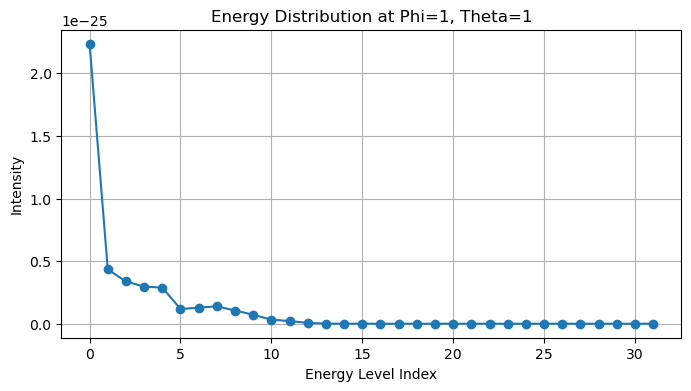

In [185]:
phi_bin = 1  # First phi bin
theta_bin = 1  # First theta bin
energy_levels = np.arange(32)  # Assuming 32 energy levels

plt.figure(figsize=(8, 4))
plt.plot(energy_levels, X_test_squeezed[0, phi_bin, theta_bin, :32], marker='o')
plt.title(f'Energy Distribution at Phi={phi_bin}, Theta={theta_bin}')
plt.xlabel('Energy Level Index')
plt.ylabel('Intensity')
plt.grid(True)
plt.show()

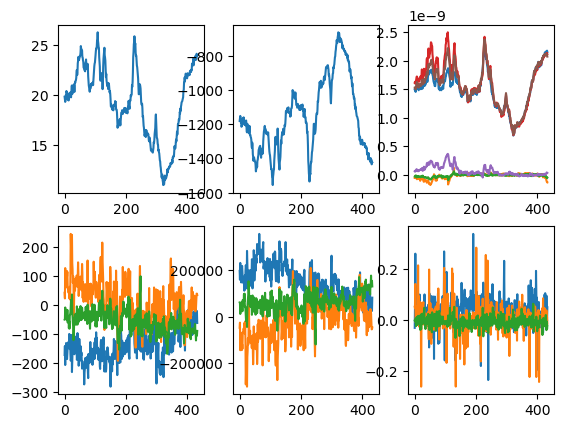

In [179]:
import cdflib

from skymaps.skymap import Skymap, plotMomentsTimeSeries


f = X_test_squeezed

# Timestep Azimuth Elevation Energy
f = f.transpose(0, 3, 2, 1)
# Timestep Energy Elevation Azimuth

steps = f.shape[0]
skymap = Skymap(steps, "MMS1_skymaps", nen=f.shape[1])
skymap.skymap = f
moments = skymap.momsTS

plotMomentsTimeSeries(moments)

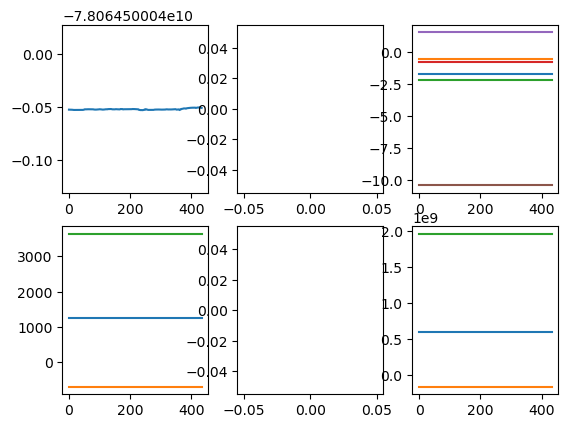

In [180]:
import cdflib

from skymaps.skymap import Skymap, plotMomentsTimeSeries


f = final_predictions

# Timestep Azimuth Elevation Energy
f = f.transpose(0, 3, 2, 1)
# Timestep Energy Elevation Azimuth

steps = f.shape[0]
skymap = Skymap(steps, "MMS1_skymaps", nen=f.shape[1])
skymap.skymap = f
moments = skymap.momsTS

plotMomentsTimeSeries(moments)

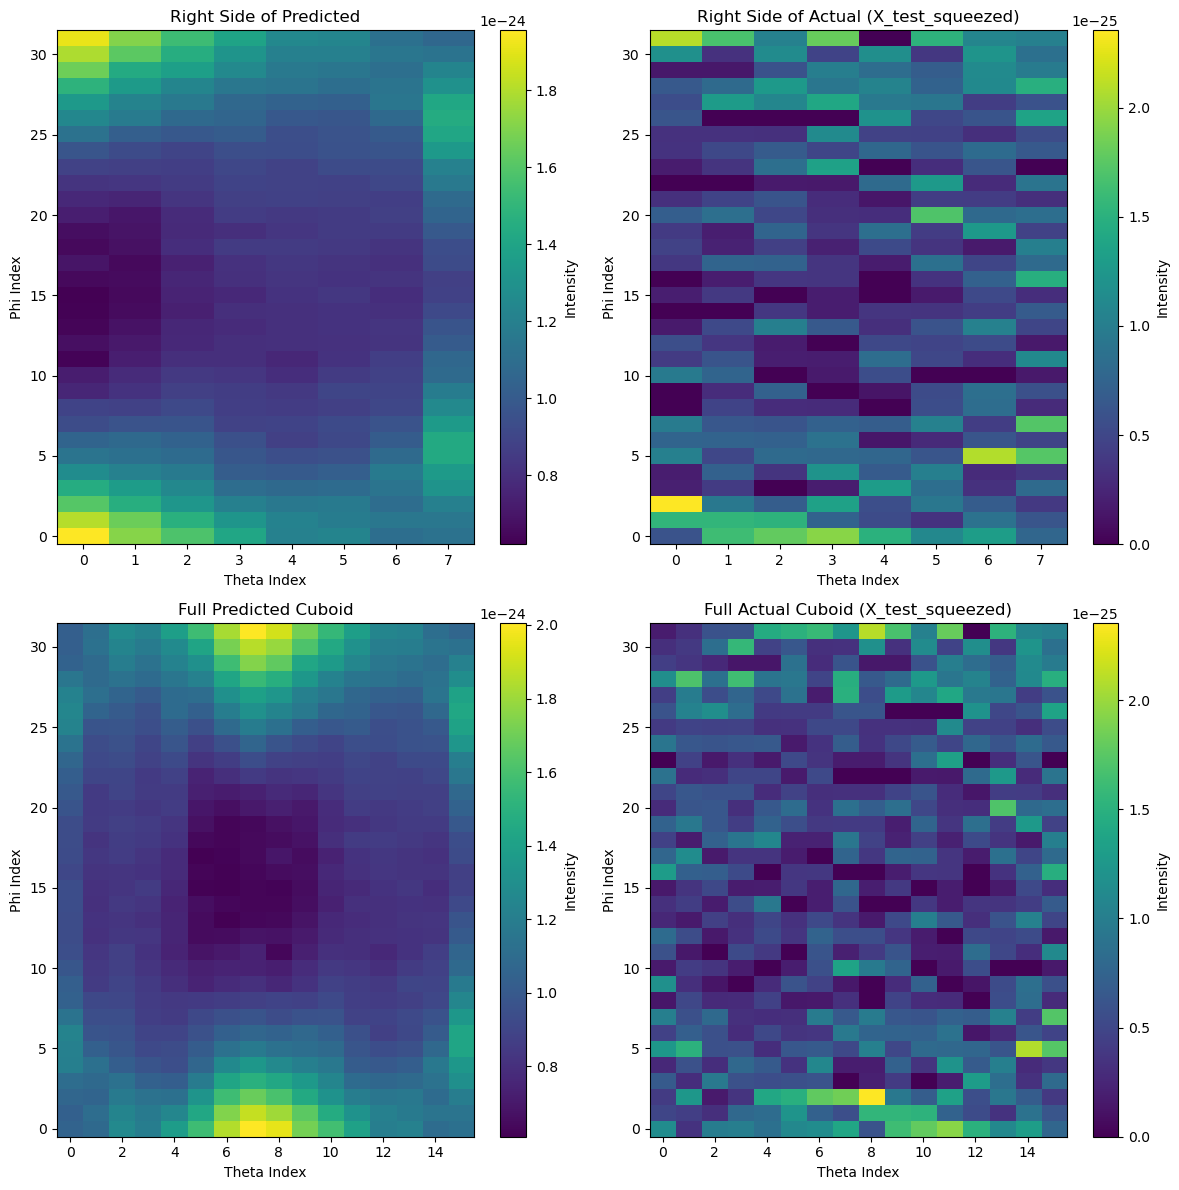

In [127]:
import matplotlib.pyplot as plt

# Select time and energy level to visualize
time_index = 0  # Change this to iterate over timesteps
energy_channel = 1  # Change this to iterate over energy channels

# Extract the right side of the prediction and actual for comparison
right_predicted = final_predictions[time_index, :, theta_bins // 2:, energy_channel]
right_actual = X_test_squeezed[time_index, :, theta_bins // 2:, energy_channel]

# Extract the full cuboid for comparison
full_predicted = final_predictions[time_index, :, :, energy_channel]
full_actual = X_test_squeezed[time_index, :, :, energy_channel]

# Plot the comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Right-hand side of the cuboid
im1 = axes[0, 0].imshow(right_predicted, aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title("Right Side of Predicted")
axes[0, 0].set_xlabel("Theta Index")
axes[0, 0].set_ylabel("Phi Index")
plt.colorbar(im1, ax=axes[0, 0], label='Intensity')

im2 = axes[0, 1].imshow(right_actual, aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title("Right Side of Actual (X_test_squeezed)")
axes[0, 1].set_xlabel("Theta Index")
axes[0, 1].set_ylabel("Phi Index")
plt.colorbar(im2, ax=axes[0, 1], label='Intensity')

# Full cuboid comparison
im3 = axes[1, 0].imshow(full_predicted, aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title("Full Predicted Cuboid")
axes[1, 0].set_xlabel("Theta Index")
axes[1, 0].set_ylabel("Phi Index")
plt.colorbar(im3, ax=axes[1, 0], label='Intensity')

im4 = axes[1, 1].imshow(full_actual, aspect='auto', origin='lower', cmap='viridis')
axes[1, 1].set_title("Full Actual Cuboid (X_test_squeezed)")
axes[1, 1].set_xlabel("Theta Index")
axes[1, 1].set_ylabel("Phi Index")
plt.colorbar(im4, ax=axes[1, 1], label='Intensity')

plt.tight_layout()
plt.show()
